In [4]:
# %pip install numpy torch torchvision scikit-learn matplotlib pillow 
import os
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:48:34) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.3.1
Torchvision version 0.18.1a0
Numpy version 1.26.4
Pandas version 2.2.2


In [5]:
class SpectrogramImagesDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [6]:
dataset = SpectrogramImagesDataset(
    data_dir=r'D:\Dataset_Sationary_Spectrograms\train'
)

In [7]:
len(dataset)

14760

0


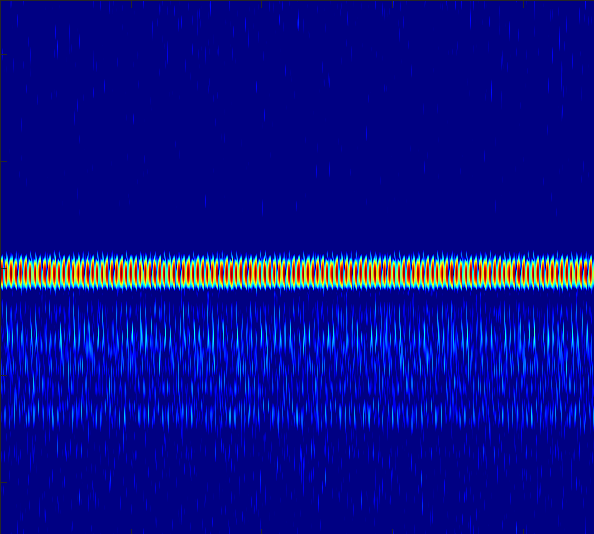

In [8]:
image, label = dataset[125]
print(label)
image

In [9]:
# Get a dictionary associating target values with folder names
data_dir = r'D:\Dataset_Sationary_Spectrograms\train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'environment', 1: 'hexacoptor', 2: 'phantom', 3: 'rcplane1', 4: 'rcplane2'}


In [10]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = r'D:\Dataset_Sationary_Spectrograms\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [11]:
# Model definitions using VGG16 and VGG19
class CustomVGG(nn.Module):
    def __init__(self, base_model, num_classes):
        super(CustomVGG, self).__init__()
        self.features = base_model.features
        self.avgpool = base_model.avgpool
        self.classifier = nn.Sequential(
            nn.Linear(base_model.classifier[0].in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Initialize models
# vgg16_base = models.vgg16(pretrained=True)
# for param in vgg16_base.parameters():
#     param.requires_grad = False
# model_vgg16 = CustomVGG(vgg16_base, num_classes=5)

vgg19_base = models.vgg19(pretrained=True)
for param in vgg19_base.parameters():
    param.requires_grad = False
model_vgg19 = CustomVGG(vgg19_base, num_classes=5)

d:\Softwares\envs\Anaconda_Projects\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Softwares\envs\Anaconda_Projects\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_dir = r'D:\Dataset_Sationary_Spectrograms\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [ ]:
# Correct folder paths
train_folder = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\train'
valid_folder =  r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\valid'
test_folder = r'D:\FYP-SignalProcessing\DroneSwarmsImages\Wavelet_Plots\Scalogram_Dataset\test'

In [13]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_folder = r'D:\Dataset_Sationary_Spectrograms\train'
valid_folder = r'D:\Dataset_Sationary_Spectrograms\valid'
test_folder = r'D:\Dataset_Sationary_Spectrograms\test'

train_dataset = SpectrogramImagesDataset(train_folder, transform=transform)
val_dataset = SpectrogramImagesDataset(valid_folder, transform=transform)
test_dataset = SpectrogramImagesDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [14]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vgg19.to(device)

CustomVGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1)

In [15]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
#optimizer_vgg16 = optim.Adam(model_vgg16.classifier.parameters(), lr=0.0001)
optimizer_vgg19 = optim.Adam(model_vgg19.classifier.parameters(), lr=0.0001)

In [16]:
#from tqdm import tqdm

scheduler_vgg19 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_vgg19, mode='min', factor=0.5, patience=2, min_lr=1e-7, verbose=True)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=15):
    model.train()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0
        
        # Use tqdm for progress bar
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, labels in train_loader_tqdm:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Update tqdm with the current loss
            train_loader_tqdm.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
        
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device, dtype=torch.long)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * images.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        
        scheduler.step(val_loss)
        
        # Save the best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_{model.__class__.__name__}.pt")
        
        model.train()


d:\Softwares\envs\Anaconda_Projects\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [17]:
train_model(model_vgg19, train_loader, val_loader, criterion, optimizer_vgg19, scheduler_vgg19)

Epoch 1/15:   0%|          | 0/1845 [00:00<?, ?it/s]

Epoch [1/15], Loss: 0.5841, Accuracy: 0.7747
Validation Loss: 0.5130, Accuracy: 0.8075


Epoch 2/15:   0%|          | 0/1845 [00:00<?, ?it/s]

Epoch [2/15], Loss: 0.2850, Accuracy: 0.8948
Validation Loss: 0.5029, Accuracy: 0.8108


Epoch 3/15:   0%|          | 0/1845 [00:00<?, ?it/s]

...

Epoch [4/15], Loss: 0.1660, Accuracy: 0.9428
Validation Loss: 0.3604, Accuracy: 0.8601


Epoch 5/15:   0%|          | 0/1845 [00:00<?, ?it/s]

Epoch [5/15], Loss: 0.1418, Accuracy: 0.9496
Validation Loss: 0.3747, Accuracy: 0.8584


Epoch 6/15:   0%|          | 0/1845 [00:00<?, ?it/s]

KeyboardInterrupt: 

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       144
     Class 1       0.57      0.23      0.33       168
     Class 2       0.95      0.96      0.96       508
     Class 3       0.80      0.78      0.79       508
     Class 4       0.78      0.95      0.86       508

    accuracy                           0.84      1836
   macro avg       0.82      0.78      0.79      1836
weighted avg       0.83      0.84      0.83      1836



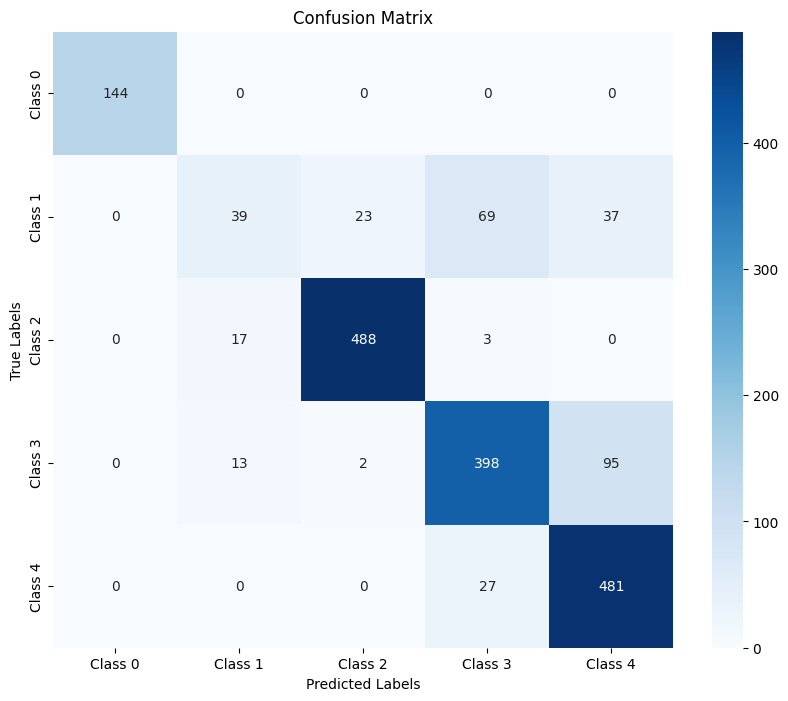

In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import transforms, datasets
import os

def test_model(model, test_loader, num_classes, checkpoint_path, device):
    """
    Tests a model, generates a classification report, and plots a confusion matrix.
    
    Parameters:
    - model: The PyTorch model to test.
    - test_loader: DataLoader for the test set.
    - num_classes: Number of classes in the dataset.
    - checkpoint_path: Path to the saved model checkpoint.
    - device: Device to run the model on (CPU or GPU).
    
    Returns:
    - classification_report: A string representation of the classification report.
    - confusion_matrix: The confusion matrix as a 2D numpy array.
    """
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = [f"Class {i}" for i in range(num_classes)]
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    return report, cm

# Example Usage:
# Assuming `test_loader` is already defined, `model_vgg19` is your model, and device is 'cuda' or 'cpu'.
checkpoint_path = "best_model_CustomVGG.pt"
report, cm = test_model(model_vgg19, test_loader, num_classes=5, checkpoint_path=checkpoint_path, device=device)


              precision    recall  f1-score   support

 environment       1.00      1.00      1.00       144
  hexacoptor       0.57      0.23      0.33       168
     phantom       0.95      0.96      0.96       508
    rcplane1       0.80      0.78      0.79       508
    rcplane2       0.78      0.95      0.86       508

    accuracy                           0.84      1836
   macro avg       0.82      0.78      0.79      1836
weighted avg       0.83      0.84      0.83      1836



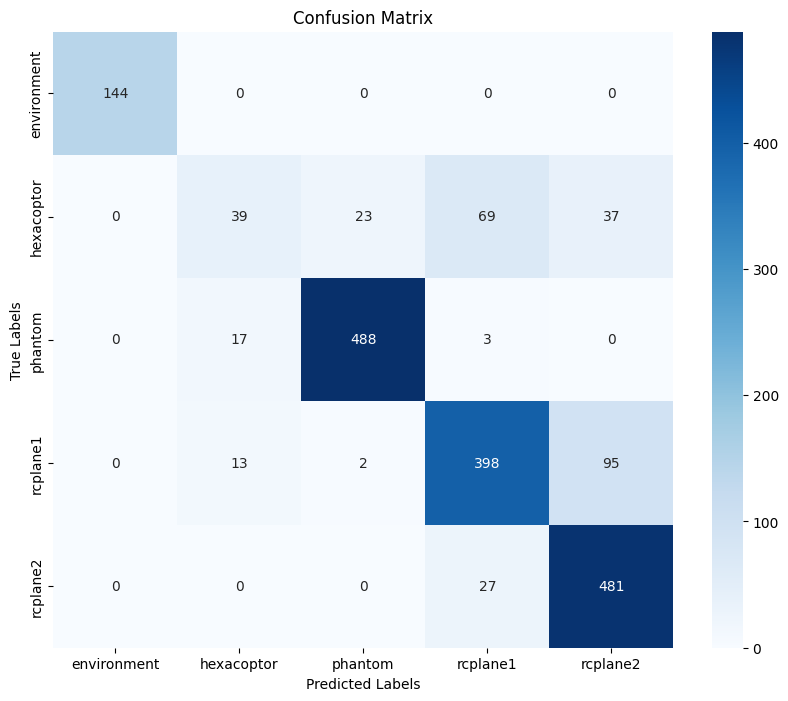

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import datasets
import os

def test_model(model, test_loader, target_to_class, checkpoint_path, device):
    """
    Tests a model, generates a classification report, and plots a confusion matrix using class names.
    
    Parameters:
    - model: The PyTorch model to test.
    - test_loader: DataLoader for the test set.
    - target_to_class: Dictionary mapping numeric class indices to class names.
    - checkpoint_path: Path to the saved model checkpoint.
    - device: Device to run the model on (CPU or GPU).
    
    Returns:
    - classification_report: A string representation of the classification report.
    - confusion_matrix: The confusion matrix as a 2D numpy array.
    """
    # Load model weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = [target_to_class[idx] for idx in range(len(target_to_class))]
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    return report, cm

# Example Usage:
# Assuming `test_loader` is already defined, `model_vgg19` is your model, and device is 'cuda' or 'cpu'.
from torchvision.datasets import ImageFolder
data_dir = r'D:\Dataset_Sationary_Spectrograms\test'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}

checkpoint_path = "best_model_CustomVGG.pt"
report, cm = test_model(model_vgg19, test_loader, target_to_class, checkpoint_path, device=device)
